In [1]:
import os
import sys

# Add local directories to sys.path
sys.path.append(os.path.abspath("../data"))
sys.path.append(os.path.abspath("../network"))

import torch
import numpy as np

# Local imports
import load
from load import ParallelMelspecDataset, collate_fn
from modules import KameBlock
from kenku import KenkuTeacher

from typing import Union, List, Tuple, Optional

from torch import nn, Tensor
from torch.utils.data import DataLoader

from tqdm import tqdm

In [2]:
rng = np.random.default_rng(42)
batch_size = 32
lrate = 5e-5

dataset = ParallelMelspecDataset(melspec_dir = "../../Data/processed/VCTK/melspec", 
                                 transcript_dir = "../../Data/processed/VCTK/transcript_standardized",
                                 speaker_properties_path = "../../Data/processed/VCTK/speaker_properties.csv",
                                 min_samples_per_sentence = 10,
                                 rng = rng)

loader = DataLoader(
  dataset, 
  batch_size=batch_size,
  shuffle=True,
  num_workers=0,  # Set to 0 or os.cpu_count() depending on the environment
  drop_last=True,
  collate_fn=collate_fn
)

model = KenkuTeacher(80, 80, 80, 80, 2, 2)

optimizer = torch.optim.Adam(model.parameters(), lr=lrate, betas=(0.9, 0.999))

In [3]:
epochs = 1
losses = []

for epoch in range(epochs):
  print(f"===== Epoch {epoch} =====")
  
  for batch in tqdm(loader, total=len(dataset) // batch_size):
    src_mels, tgt_mels, src_mask, tgt_mask, src_props, tgt_props = batch
    loss = model.calc_loss(*batch)
    
    loss_val = loss.item()
    losses.append(loss_val)
    
    model.zero_grad()
    loss.backward()
    optimizer.step()
    

===== Epoch 0 =====


  5%|▌         | 22/422 [01:19<24:13,  3.63s/it]


KeyboardInterrupt: 

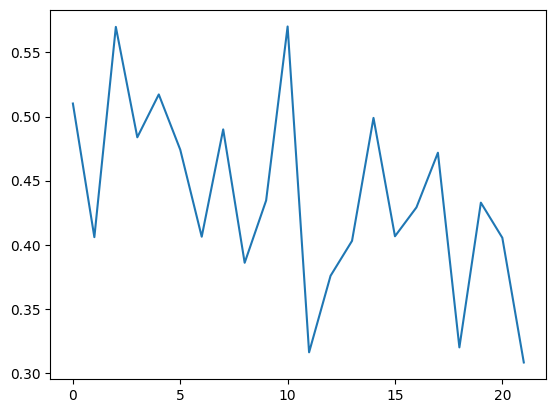

In [4]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), losses)
plt.show()